# Аппроксимация функций: полный GD, SGD, мини-батчи, NAG

Задача: по набору точек $(x_i, y_i)$ подобрать веса параметрической модели $a(x) = w^{\top} s(x)$,
минимизируя среднеквадратичный эмпирический риск

$$Q(w) = \frac{1}{n}\sum_{i=1}^{n} \big(a(x_i) - y_i\big)^2.$$

Смотрим, как с этим справляются разные варианты градиентного спуска:

- **полный GD** — градиент считается сразу по всей выборке;
- **SGD** — шаг по одному случайному объекту;
- **мини-батч SGD** — шаг по случайной подвыборке размера $K$;
- **NAG** — мини-батч версия с импульсом Нестерова.

За процессом обучения слежу через экспоненциальное скользящее среднее ошибки:
$Qe \leftarrow \lambda Q_k + (1-\lambda) Qe$. Всё на чистом numpy.


## 1. Полный градиентный спуск (батч = вся выборка)

Аппроксимируем $f(x) = 0.1x^2 - \sin x + 5$ кубическим полиномом
$a(x) = w_0 + w_1 x + w_2 x^2 + w_3 x^3$.

Градиент по весам: $\nabla Q = \frac{2}{n} S^{\top} (Sw - y)$, где $S$ — матрица
признаков $[1, x, x^2, x^3]$. Считаю её один раз до цикла, чтобы не множить
матрицы на каждой итерации.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def func(x):
    return 0.1 * x ** 2 - np.sin(x) + 5.0


coord_x = np.arange(-5.0, 5.0, 0.1)
coord_y = func(coord_x)
sz = len(coord_x)

eta = np.array([0.1, 0.01, 0.001, 0.0001])  # свой шаг для каждого веса
w = np.zeros(4)
N = 200

# матрица признаков (sz, 4): строка — [1, x, x^2, x^3]
S = np.column_stack((np.ones(sz), coord_x, coord_x ** 2, coord_x ** 3))

Q_history = []
for _ in range(N):
    error = S @ w - coord_y              # ошибки по всем точкам сразу
    gradient = (2.0 / sz) * (S.T @ error)
    w = w - eta * gradient
    Q_history.append(np.mean(error ** 2))

Q_gd = np.mean((S @ w - coord_y) ** 2)
print(f"итоговое MSE: {Q_gd:.5f}")
print(f"веса: {np.round(w, 4)}")


итоговое MSE: 0.13061
веса: [ 4.9865 -0.4178  0.1027  0.0317]


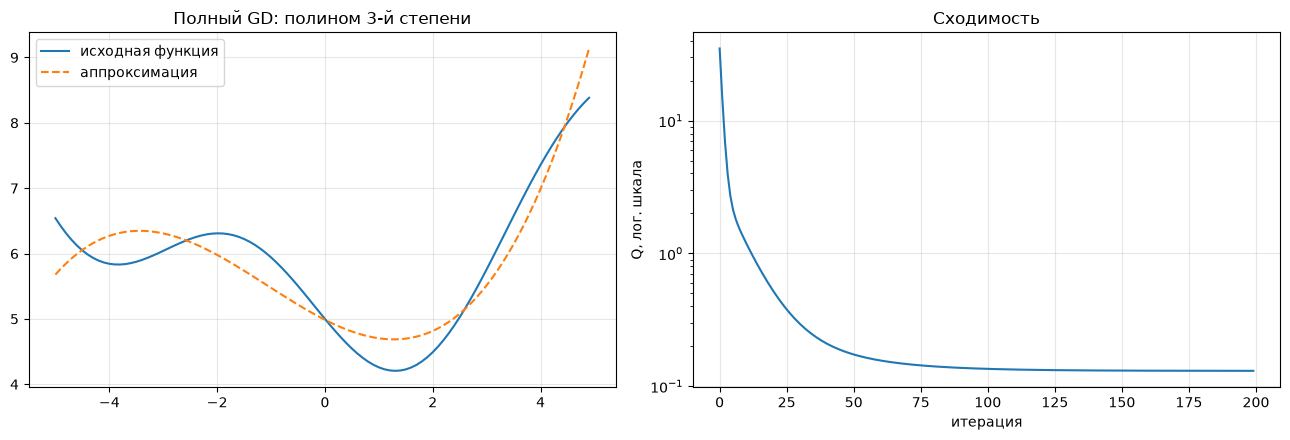

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(coord_x, coord_y, label="исходная функция")
ax[0].plot(coord_x, S @ w, "--", label="аппроксимация")
ax[0].set_title("Полный GD: полином 3-й степени")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(Q_history)
ax[1].set_yscale("log")
ax[1].set_xlabel("итерация")
ax[1].set_ylabel("Q, лог. шкала")
ax[1].set_title("Сходимость")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


MSE порядка 0.13 — полином третьей степени неплохо держит форму функции,
хотя синус внутри $f$ полиномом до конца не ловится. Шаги $\eta$ подобраны разные для
каждого веса: старшие степени $x$ дают огромные значения признаков, и с единым шагом
градиент по ним взорвался бы.

## 2. SGD по одному случайному объекту

Теперь функция похитрее: $f(x) = 0.02\,e^{-x} - 0.2\sin 3x + 0.5\cos 2x - 7$,
модель — полином 4-й степени. Обновление идёт по одному случайному объекту за шаг.


In [3]:
def func2(x):
    return 0.02 * np.exp(-x) - 0.2 * np.sin(3 * x) + 0.5 * np.cos(2 * x) - 7


# модель и квадратичная функция потерь по одному объекту
def model(w, x):
    return x @ w


def loss(w, x, y):
    return (model(w, x) - y) ** 2


def dloss(w, x, y):
    # градиент квадратичной потери по w
    return 2 * (x @ w - y) * x


coord_x2 = np.arange(-5.0, 5.0, 0.1)
coord_y2 = func2(coord_x2)
x_train2 = np.array([[1, x, x ** 2, x ** 3, x ** 4] for x in coord_x2])

sz2 = len(coord_x2)
eta2 = np.array([0.01, 1e-3, 1e-4, 1e-5, 1e-6])
w2 = np.zeros(5)
N = 500
lm = 0.02  # коэффициент скользящего среднего

np.random.seed(0)
Qe = np.mean(loss(w2, x_train2, coord_y2))
Qe_history = []

for _ in range(N):
    k = np.random.randint(0, sz2 - 1)   # случайный объект
    x_k, y_k = x_train2[k], coord_y2[k]

    w2 -= eta2 * dloss(w2, x_k, y_k)

    Qe = loss(w2, x_k, y_k) * lm + Qe * (1 - lm)
    Qe_history.append(Qe)

Q_sgd = np.mean(loss(w2, x_train2, coord_y2))
print(f"итоговое MSE по всей выборке: {Q_sgd:.5f}")
print(f"скользящее среднее Qe: {Qe:.5f}")


итоговое MSE по всей выборке: 0.26997
скользящее среднее Qe: 0.19370


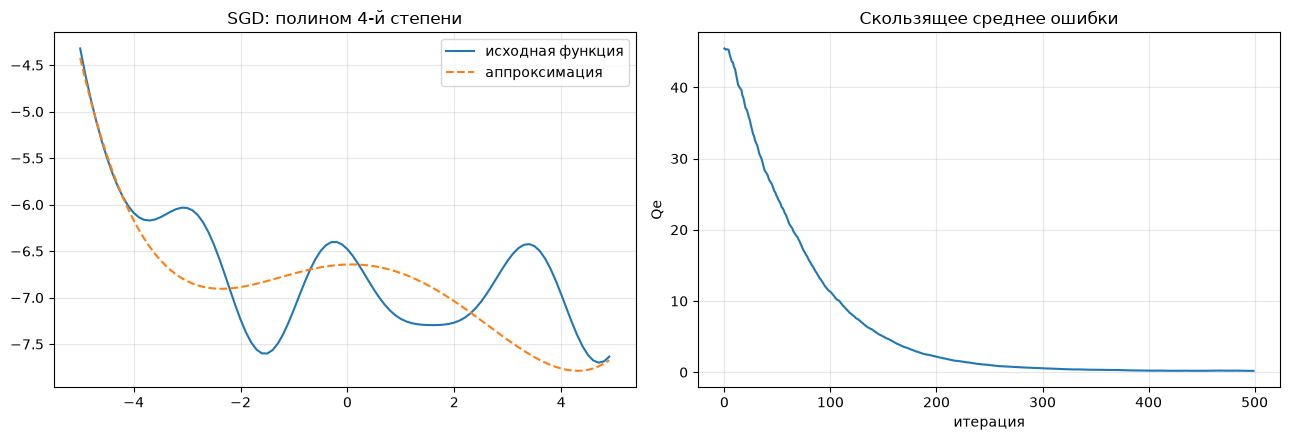

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(coord_x2, coord_y2, label="исходная функция")
ax[0].plot(coord_x2, x_train2 @ w2, "--", label="аппроксимация")
ax[0].set_title("SGD: полином 4-й степени")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(Qe_history)
ax[1].set_xlabel("итерация")
ax[1].set_ylabel("Qe")
ax[1].set_title("Скользящее среднее ошибки")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Всего 500 шагов по одному объекту, и MSE уже на уровне десятых долей.
По кривой $Qe$ видно, как сильно прыгает ошибка от объекта к объекту: это нормально
для SGD, скользящее среднее как раз и сглаживает этот шум.

## 3. SGD с тригонометрическим базисом

Функция $f(x) = 0.5x^2 - 0.1\,e^{x} + 0.5\cos 2x - 2$, базис модели:
$[1,\; x,\; x^2,\; \cos 2x,\; \sin 2x]$. Раз в $f$ есть $\cos 2x$, такой базис
подходит ей гораздо лучше голого полинома.


In [5]:
def func3(x):
    # исходная запись 0.1 * 1/np.exp(-x) — это то же самое, что 0.1 * e^x
    return 0.5 * x ** 2 - 0.1 * np.exp(x) + 0.5 * np.cos(2 * x) - 2.0


coord_x3 = np.arange(-5.0, 5.0, 0.1)
coord_y3 = func3(coord_x3)

sz3 = len(coord_x3)
eta3 = np.array([0.01, 0.001, 0.0001, 0.01, 0.01])
w3 = np.zeros(5)
N = 500
lm = 0.02


def basis(x):
    return np.array([1, x, x ** 2, np.cos(2 * x), np.sin(2 * x)])


np.random.seed(0)
Qe3 = np.mean((coord_y3 - (w3 @ np.array([basis(x) for x in coord_x3]).T)) ** 2)
Qe3_history = []

for _ in range(N):
    k = np.random.randint(0, sz3)
    s = basis(coord_x3[k])
    y_pred = w3 @ s

    w3 = w3 - eta3 * 2 * (y_pred - coord_y3[k]) * s

    Qe3 = lm * (y_pred - coord_y3[k]) ** 2 + (1 - lm) * Qe3
    Qe3_history.append(Qe3)

S3 = np.array([basis(x) for x in coord_x3])
Q_trig = np.mean((S3 @ w3 - coord_y3) ** 2)
print(f"итоговое MSE: {Q_trig:.5f}")
print(f"веса: {np.round(w3, 4)}")


итоговое MSE: 1.43234
веса: [-1.5587 -0.7713  0.2866  0.8162 -0.1401]


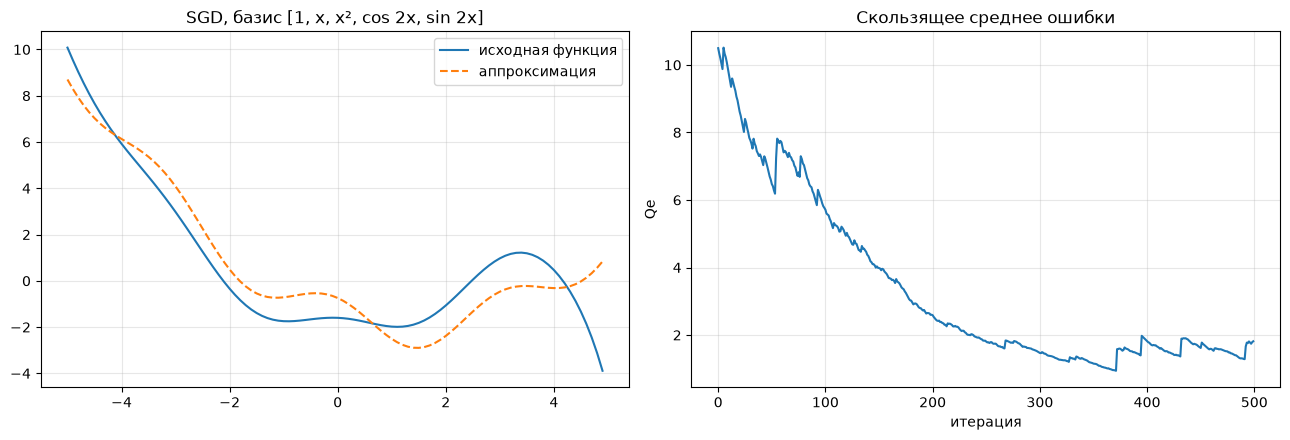

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(coord_x3, coord_y3, label="исходная функция")
ax[0].plot(coord_x3, S3 @ w3, "--", label="аппроксимация")
ax[0].set_title("SGD, базис [1, x, x², cos 2x, sin 2x]")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(Qe3_history)
ax[1].set_xlabel("итерация")
ax[1].set_ylabel("Qe")
ax[1].set_title("Скользящее среднее ошибки")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Здесь MSE заметно выше, чем в соседних разделах (около 1.4), и это
принципиальный момент: в базисе нет ничего похожего на экспоненту $e^x$, поэтому член
$-0.1\,e^x$ модель выразить не в состоянии — на правом краю отрезка ошибка и концентрируется.
Тригонометрическую часть базис при этом подхватывает: вес при $\cos 2x$ получается
положительным и сопоставимым с истинным $0.5$. Проверял и с бо́льшим числом итераций
(до 20000): MSE так и держится около 1.4, то есть упор идёт в выразительную силу
базиса, а не в оптимизатор.

## 4. Мини-батч SGD

Та же задача, но шаг считается по $K = 50$ случайным объектам сразу.
Функция $f(x) = 0.5x + 0.2x^2 - 0.05x^3 + 0.2\sin 4x - 2.5$, модель — кубический полином.


In [7]:
def func4(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.05 * x ** 3 + 0.2 * np.sin(4 * x) - 2.5


coord_x4 = np.arange(-4.0, 6.0, 0.1)
coord_y4 = func4(coord_x4)

sz4 = len(coord_x4)
eta4 = np.array([0.1, 0.01, 0.001, 0.0001])
w4 = np.zeros(4)
N = 500
lm = 0.02
batch_size = 50

np.random.seed(0)
S4 = np.array([[1, x, x ** 2, x ** 3] for x in coord_x4])
Qe4 = np.mean((S4 @ w4 - coord_y4) ** 2)
Qe4_history = []

for _ in range(N):
    k = np.random.randint(0, sz4 - batch_size)
    s = S4[k:k + batch_size]            # (50, 4)
    y = coord_y4[k:k + batch_size]

    y_pred = s @ w4
    grad = 2 / batch_size * s.T @ (y_pred - y)
    w4 = w4 - eta4 * grad

    Qk = np.mean((y_pred - y) ** 2)
    Qe4 = lm * Qk + (1 - lm) * Qe4
    Qe4_history.append(Qe4)

Q_batch = np.mean((S4 @ w4 - coord_y4) ** 2)
print(f"итоговое MSE: {Q_batch:.5f}")
print(f"веса: {np.round(w4, 4)}")


итоговое MSE: 0.02011
веса: [-2.4973  0.4945  0.1976 -0.0497]


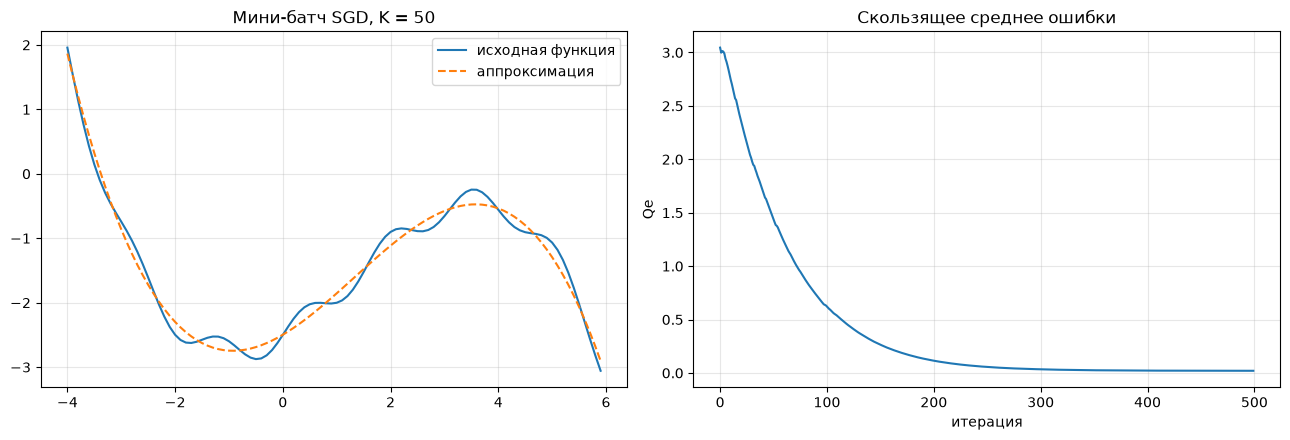

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(coord_x4, coord_y4, label="исходная функция")
ax[0].plot(coord_x4, S4 @ w4, "--", label="аппроксимация")
ax[0].set_title("Мини-батч SGD, K = 50")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(Qe4_history)
ax[1].set_xlabel("итерация")
ax[1].set_ylabel("Qe")
ax[1].set_title("Скользящее среднее ошибки")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


По сравнению с покадровым SGD кривая $Qe$ заметно ровнее: усреднение
градиента по 50 объектам гасит шум. При этом по времени 500 мини-батчей — это примерно
250 эпох по выборке, так что качество успевает устаканиться.

## 5. Мини-батч SGD с импульсом Нестерова (NAG)

Функция $f(x) = -0.7x - 0.2x^2 + 0.05x^3 - 0.2\cos 3x + 2$, кубический полином,
$K = 20$, $\gamma = 0.8$. Импульс пересчитывается по формуле
$v \leftarrow \gamma v + (1-\gamma)\,\eta\,\nabla Q(w - \gamma v)$.


In [9]:
def func5(x):
    return -0.7 * x - 0.2 * x ** 2 + 0.05 * x ** 3 - 0.2 * np.cos(3 * x) + 2


def Q(w, X, y):
    return np.mean(np.square(X @ w - y))


def dQdw(w, X, y):
    return X.T @ (X @ w - y) * (2 / X.shape[0])


coord_x5 = np.arange(-4.0, 6.0, 0.1)
coord_y5 = func5(coord_x5)

sz5 = len(coord_x5)
eta5 = np.array([0.1, 0.01, 0.001, 0.0001])
w5 = np.zeros(4)
N = 500
lm = 0.02
batch_size5 = 20
gamma5 = 0.8
v5 = np.zeros(4)   # вектор импульса

X5 = np.array([[1, x, x ** 2, x ** 3] for x in coord_x5])
y5 = np.array(coord_y5)

np.random.seed(0)
Qe5 = Q(w5, X5, y5)
Qe5_history = []

for _ in range(N):
    k = np.random.randint(0, sz5 - batch_size5 - 1)
    Xk = X5[k:k + batch_size5]
    yk = y5[k:k + batch_size5]

    Qe5 = lm * Q(w5, Xk, yk) + (1 - lm) * Qe5
    Qe5_history.append(Qe5)

    # градиент берём в точке «забегания вперёд» w - gamma * v
    v5 = gamma5 * v5 + (1 - gamma5) * eta5 * dQdw(w5 - gamma5 * v5, Xk, yk)
    w5 -= v5

Q_nag = Q(w5, X5, y5)
print(f"итоговое MSE: {Q_nag:.5f}")
print(f"веса: {np.round(w5, 4)}")


итоговое MSE: 0.02024
веса: [ 2.0009 -0.6942 -0.1973  0.0491]


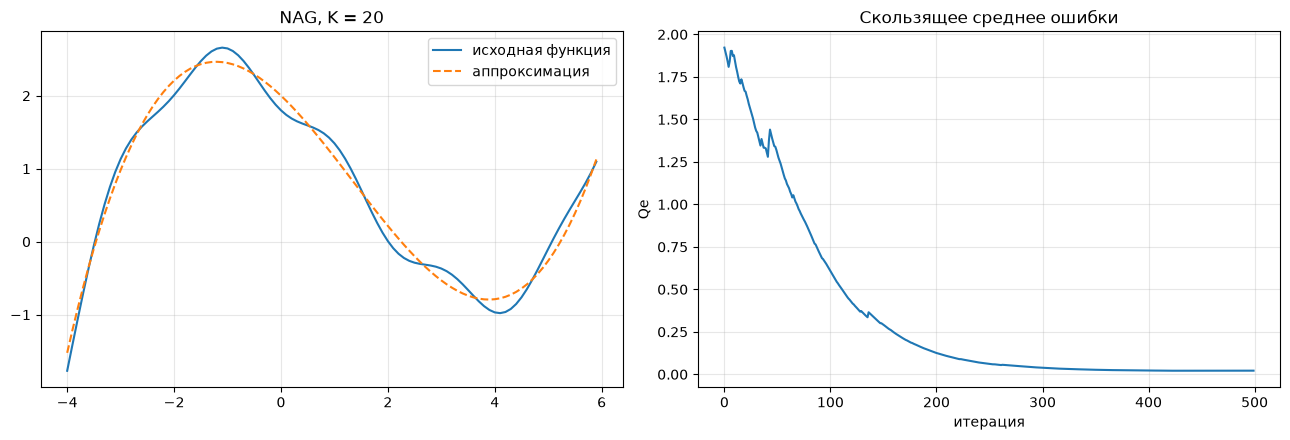

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(coord_x5, coord_y5, label="исходная функция")
ax[0].plot(coord_x5, X5 @ w5, "--", label="аппроксимация")
ax[0].set_title("NAG, K = 20")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(Qe5_history)
ax[1].set_xlabel("итерация")
ax[1].set_ylabel("Qe")
ax[1].set_title("Скользящее среднее ошибки")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
print("Сводка по методам (итоговое MSE):")
print(f"  полный GD, полином 3-й ст.   : {Q_gd:.5f}")
print(f"  SGD, полином 4-й ст.         : {Q_sgd:.5f}")
print(f"  SGD, тригонометрич. базис    : {Q_trig:.5f}")
print(f"  мини-батч SGD, K=50          : {Q_batch:.5f}")
print(f"  NAG, K=20                    : {Q_nag:.5f}")


Сводка по методам (итоговое MSE):
  полный GD, полином 3-й ст.   : 0.13061
  SGD, полином 4-й ст.         : 0.26997
  SGD, тригонометрич. базис    : 1.43234
  мини-батч SGD, K=50          : 0.02011
  NAG, K=20                    : 0.02024


## Выводы

- Все четыре схемы уверенно минимизируют ошибку: где базис подобран под задачу,
  MSE доходит до сотых долей, а кривые почти совпадают с исходными функциями.
- Полный GD самый стабильный, но каждая итерация стоит столько, сколько весь
  проход по данным, — на больших выборках это роскошь.
- Покадровый SGD шумный (это видно по $Qe$), зато дешёвый и быстро съезжает
  со старта. Мини-батч — рабочий компромисс: шум падает, цена итерации умеренная.
- NAG ведёт себя как мини-батч SGD, но с более уверенным спуском на первых
  итерациях — импульс сглаживает случайные рывки градиента.
- Качество аппроксимации упирается не в оптимизатор, а в базис. В примере 3 базис
  отлично ловит $\cos 2x$, но без экспоненты в базисе ошибка замирает около 1.4 при
  любом числе итераций. Подбор базиса важнее тонкой настройки шагов.
